In [3]:
import pandas as pd
import glob
import os

# Tìm tất cả file labeled*.csv
files = glob.glob("labeled*.csv")

all_data = []

for file_path in files:
    try:
        df = pd.read_csv(file_path)

        # Xóa dòng có text rỗng / null
        df = df.dropna(subset=["text"])
        df = df[df["text"].astype(str).str.strip() != ""]

        # Chỉ giữ các cột cần thiết
        df = df[['text', 'food', 'service', 'place', 'price']]

        print(f"✅ {file_path}: {len(df)} reviews hợp lệ")

        all_data.append(df)

    except Exception as e:
        print(f"❌ Lỗi {file_path}: {e}")

# Gộp tất cả dữ liệu
merged_df = pd.concat(all_data, ignore_index=True)

print("\n===== SAU KHI GỘP =====")
print(merged_df.head())

print(f"\nTổng số review hợp lệ: {len(merged_df)}")

# Chỉ giữ label 0,1,2,3
cols = ['food', 'service', 'place', 'price']

merged_df = merged_df[
    merged_df[cols].isin([0, 1, 2, 3]).all(axis=1)
]

print("Shape after label filtering:", merged_df.shape)

# Drop duplicate text
merged_df = merged_df.drop_duplicates(subset=['text'])

print("Shape after dropping duplicate text:", merged_df.shape)

# Lưu file
merged_df.to_csv("11k_google_maps_reviews.csv", index=False)

print("\n💾 Đã lưu: google_maps_reviews.csv")

✅ labeled_20260517_153754.csv: 120 reviews hợp lệ
✅ labeled_20260517_154537.csv: 100 reviews hợp lệ
✅ labeled_20260517_160144.csv: 420 reviews hợp lệ
✅ labeled_20260517_161608.csv: 600 reviews hợp lệ
✅ labeled_20260517_162936.csv: 300 reviews hợp lệ
✅ labeled_20260517_163828.csv: 400 reviews hợp lệ
✅ labeled_20260517_165933.csv: 400 reviews hợp lệ
✅ labeled_20260517_171234.csv: 100 reviews hợp lệ
✅ labeled_20260517_173838.csv: 100 reviews hợp lệ
✅ labeled_20260517_220608.csv: 5400 reviews hợp lệ
✅ labeled_20260517_233812.csv: 3200 reviews hợp lệ

===== SAU KHI GỘP =====
                                                text  food  service  place  \
0  Xôi cua! Thật sự là một phần nhỏ nhưng rất ngo...     2        0      0   
1             Tệ nhân viên thái độ đồ ăn bình thường     3        1      0   
2      Nhân viên bất lịch sự\nChén mẻ\nĐồ ăn ko ngon     1        1      1   
3   Phục vụ chậm, lơ là. Thái độ nhân viên khó chịu.     0        1      0   
4                 Quán ăn ngon, r

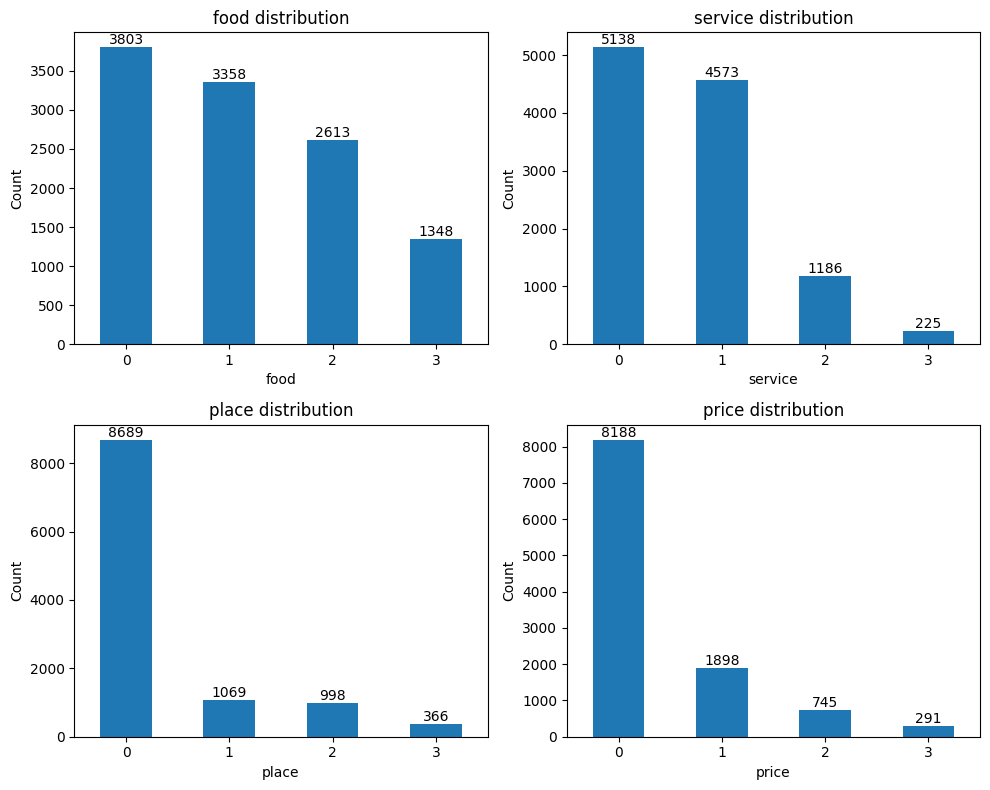

In [4]:
import matplotlib.pyplot as plt

cols = ['food', 'service', 'place', 'price']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for ax, col in zip(axes, cols):
    counts = merged_df[col].value_counts().sort_index()

    counts.plot(kind='bar', ax=ax)

    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

    # Value labels
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()